# POSTTEST 2 — DATA PREPROCESSING
## Tokyo 2020 Olympic Games


## 1. Import Library

Library yang digunakan:
- Pandas dan NumPy untuk pengolahan data.
- Matplotlib dan Seaborn untuk pemeriksaan/visualisasi data.
- Scikit-learn untuk standardisasi dan One-Hot Encoding.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

## 2. Upload dan Membaca Dataset

Dataset Tokyo 2020 yang digunakan adalah `medals_total.csv`.

Jika file CSV sudah tersedia di folder Colab, kode akan langsung membacanya. Jika belum tersedia, notebook menyediakan cara upload ZIP dataset kemudian mengekstraknya.

In [2]:
# Cek apakah dataset sudah tersedia
import os

if os.path.exists('medals_total.csv'):
    csv_path = 'medals_total.csv'
    print('medals_total.csv ditemukan di folder kerja Colab.')
else:
    print('medals_total.csv belum ditemukan.')
    print('Silakan upload ZIP dataset Tokyo 2020 pada cell berikutnya.')

medals_total.csv belum ditemukan.
Silakan upload ZIP dataset Tokyo 2020 pada cell berikutnya.


In [3]:
# Upload ZIP dataset jika diperlukan
from google.colab import files
import zipfile

uploaded = files.upload()

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('dataset_tokyo2020')

# Cari medals_total.csv secara otomatis
csv_path = 'dataset_tokyo2020/medals_total.csv'

print('Dataset berhasil diekstrak.')
print('Lokasi dataset:', csv_path)

Saving archive (6).zip to archive (6).zip
Dataset berhasil diekstrak.
Lokasi dataset: dataset_tokyo2020/medals_total.csv


### Membaca Dataset

`medals_total.csv` berisi peringkat negara serta jumlah medali emas, perak, perunggu, dan total medali pada Olimpiade Tokyo 2020.

In [4]:
df = pd.read_csv(csv_path)

print('Ukuran dataset:', df.shape)
df.head()

Ukuran dataset: (93, 7)


,Rank,Country Code,Gold Medal,Silver Medal,Bronze Medal,Total,Country
0,1,USA,39,41,33,113,United States of America
1,2,CHN,38,32,18,88,People's Republic of China
2,3,JPN,27,14,17,58,Japan
3,4,GBR,22,21,22,65,Great Britain
4,5,ROC,20,28,23,71,ROC


## 3. Pemeriksaan Struktur Dataset

Sebelum preprocessing, struktur data diperiksa untuk mengetahui jumlah baris, kolom, tipe data, dan isi awal dataset.

In [5]:
print('Jumlah records:', len(df))
print('Jumlah attributes:', len(df.columns))
print('Nama attributes:')
print(df.columns.tolist())

print('\nTipe data:')
print(df.dtypes)

print('\nInformasi dataset:')
df.info()

Jumlah records: 93
Jumlah attributes: 7
Nama attributes:
['Rank', 'Country Code', 'Gold Medal', 'Silver Medal', 'Bronze Medal', 'Total', 'Country']

Tipe data:
Rank             int64
Country Code    object
Gold Medal       int64
Silver Medal     int64
Bronze Medal     int64
Total            int64
Country         object
dtype: object

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Rank          93 non-null     int64 
 1   Country Code  93 non-null     object
 2   Gold Medal    93 non-null     int64 
 3   Silver Medal  93 non-null     int64 
 4   Bronze Medal  93 non-null     int64 
 5   Total         93 non-null     int64 
 6   Country       93 non-null     object
dtypes: int64(5), object(2)
memory usage: 5.2+ KB


# DATA CLEANING

## 4. Handling Missing Value

Missing value perlu diperiksa karena nilai kosong dapat mengganggu analisis dan proses preprocessing berikutnya.

Jika tidak terdapat missing value, tidak diperlukan imputasi atau penghapusan data karena missing value.

In [6]:
missing_values = df.isnull().sum()

print('Jumlah missing value setiap kolom:')
print(missing_values)

if missing_values.sum() == 0:
    print('\nKesimpulan: tidak terdapat missing value pada dataset.')
else:
    print('\nKesimpulan: terdapat missing value pada dataset.')

Jumlah missing value setiap kolom:
Rank            0
Country Code    0
Gold Medal      0
Silver Medal    0
Bronze Medal    0
Total           0
Country         0
dtype: int64

Kesimpulan: tidak terdapat missing value pada dataset.


## 5. Handling Duplicate Value

Duplicate value adalah baris yang memiliki isi sama dengan baris lainnya. Duplicate diperiksa agar tidak menyebabkan perhitungan menjadi bias.

Jika duplicate ditemukan, baris tersebut akan dihapus.

In [7]:
jumlah_duplicate = df.duplicated().sum()

print('Jumlah data duplicate:', jumlah_duplicate)

if jumlah_duplicate > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print('Data duplicate telah dihapus.')
else:
    print('Tidak terdapat data duplicate.')

Jumlah data duplicate: 0
Tidak terdapat data duplicate.


## 6. Handling Outlier

Outlier dideteksi menggunakan metode Interquartile Range (IQR).

Rumus:
- IQR = Q3 - Q1
- Batas bawah = Q1 - 1.5 × IQR
- Batas atas = Q3 + 1.5 × IQR

Outlier tidak langsung dihapus. Pada data Olimpiade, nilai jumlah medali yang tinggi merupakan kondisi yang valid, bukan kesalahan pencatatan. Karena itu, outlier valid dipertahankan agar informasi tidak hilang.

In [8]:
numeric_columns_original = df.select_dtypes(include='number').columns.tolist()

outlier_summary = []

for column in numeric_columns_original:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()

    outlier_summary.append({
        'Attribute': column,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Batas Bawah': lower_bound,
        'Batas Atas': upper_bound,
        'Jumlah Outlier': outlier_count
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,Attribute,Q1,Q3,IQR,Batas Bawah,Batas Atas,Jumlah Outlier
0,Rank,24.00,70.00,46.00,-45.00,139.00,0
1,Gold Medal,0.00,3.00,3.00,-4.50,7.50,10
2,Silver Medal,0.00,4.00,4.00,-6.00,10.00,8
3,Bronze Medal,1.00,5.00,4.00,-5.00,11.00,10
4,Total,2.00,11.00,9.00,-11.50,24.50,10


### Visualisasi Outlier

Boxplot digunakan untuk membantu melihat sebaran data dan nilai yang berada jauh dari bagian utama distribusi.

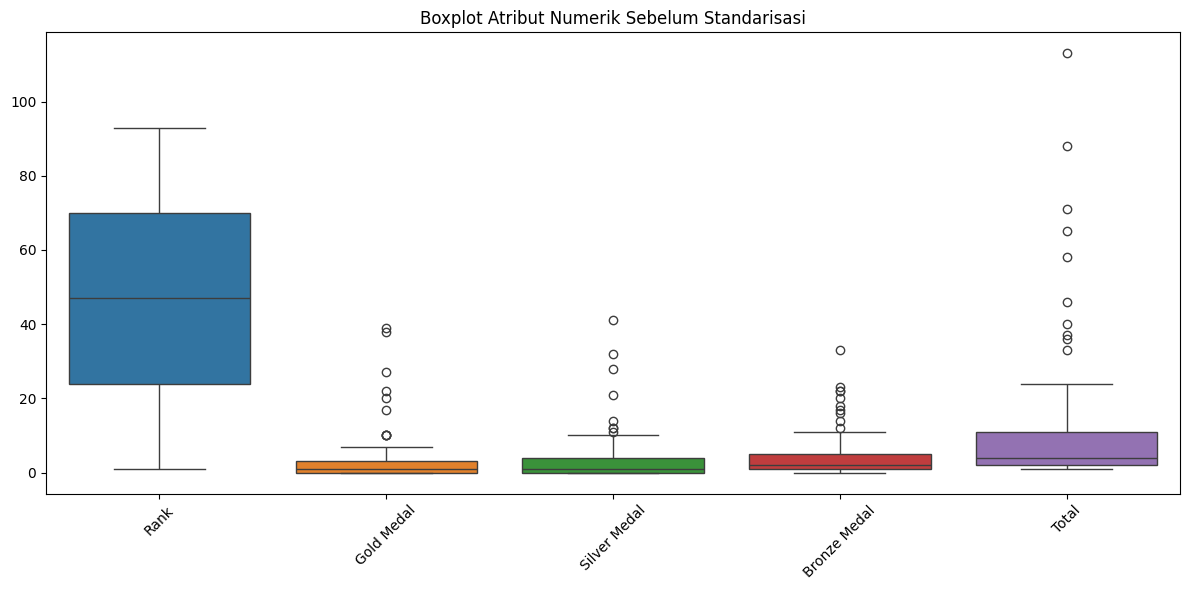

In [9]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numeric_columns_original])
plt.title('Boxplot Atribut Numerik Sebelum Standarisasi')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Keputusan Penanganan Outlier

Outlier yang terdeteksi tidak dihapus karena konteks data menunjukkan bahwa nilai tersebut merupakan observasi yang valid. Negara dengan jumlah medali yang jauh lebih tinggi memang dapat terjadi pada kompetisi Olimpiade.

Dengan demikian, proses cleaning mempertahankan nilai valid tersebut.

# FEATURE ENGINEERING

## 7. Membuat Feature Baru

Feature engineering dilakukan dengan membuat atribut baru dari data yang tersedia.

Feature baru yang dibuat adalah `Medal_Types_Won`, yaitu jumlah jenis medali yang diperoleh suatu negara.

Contoh:
- Gold > 0 dihitung 1
- Silver > 0 dihitung 1
- Bronze > 0 dihitung 1

Feature ini tidak menggunakan kolom `Rank` dan tidak dibuat sebagai target label.

In [10]:
df['Medal_Types_Won'] = (
    (df['Gold Medal'] > 0).astype(int) +
    (df['Silver Medal'] > 0).astype(int) +
    (df['Bronze Medal'] > 0).astype(int)
)

df[['Country', 'Gold Medal', 'Silver Medal', 'Bronze Medal', 'Medal_Types_Won']].head(10)

,Country,Gold Medal,Silver Medal,Bronze Medal,Medal_Types_Won
0,United States of America,39,41,33,3
1,People's Republic of China,38,32,18,3
2,Japan,27,14,17,3
3,Great Britain,22,21,22,3
4,ROC,20,28,23,3
5,Australia,17,7,22,3
6,Netherlands,10,12,14,3
7,France,10,12,11,3
8,Germany,10,11,16,3
9,Italy,10,10,20,3


Feature `Medal_Types_Won` menunjukkan seberapa banyak dari tiga jenis medali yang berhasil diperoleh setiap negara. Nilainya berkisar antara 1 sampai 3 pada dataset ini.

In [11]:
print('Jumlah feature baru:', 1)
print('Nama feature baru: Medal_Types_Won')
print('Nilai unik:', sorted(df['Medal_Types_Won'].unique()))

Jumlah feature baru: 1
Nama feature baru: Medal_Types_Won
Nilai unik: [np.int64(1), np.int64(2), np.int64(3)]


# NORMALISASI / STANDARISASI

## 8. Standardisasi Kolom Numerik

Standardisasi digunakan agar atribut numerik berada pada skala yang relatif sama.

Metode yang digunakan adalah `StandardScaler`, yang mengubah data sehingga rata-rata mendekati 0 dan standar deviasi mendekati 1.

In [12]:
numeric_columns = [
    'Rank',
    'Gold Medal',
    'Silver Medal',
    'Bronze Medal',
    'Total',
    'Medal_Types_Won'
]

scaler = StandardScaler()

df_scaled = df.copy()
df_scaled[numeric_columns] = scaler.fit_transform(df_scaled[numeric_columns])

df_scaled[numeric_columns].head(10)

,Rank,Gold Medal,Silver Medal,Bronze Medal,Total,Medal_Types_Won
0,-1.71,5.06,5.67,4.64,5.34,0.91
1,-1.68,4.92,4.30,2.21,4.02,0.91
2,-1.64,3.34,1.57,2.05,2.44,0.91
3,-1.60,2.63,2.63,2.86,2.81,0.91
4,-1.56,2.34,3.70,3.02,3.13,0.91
5,-1.53,1.91,0.51,2.86,1.81,0.91
6,-1.49,0.91,1.27,1.57,1.28,0.91
7,-1.45,0.91,1.27,1.08,1.13,0.91
8,-1.42,0.91,1.12,1.89,1.34,0.91
9,-1.38,0.91,0.97,2.54,1.49,0.91


### Memeriksa Hasil Standardisasi

Mean hasil standardisasi seharusnya mendekati 0. Pemeriksaan ini dilakukan untuk memastikan proses standardisasi berhasil.

In [13]:
print('Mean setelah standardisasi:')
print(df_scaled[numeric_columns].mean())

print('\nStandar deviasi setelah standardisasi:')
print(df_scaled[numeric_columns].std())

Mean setelah standardisasi:
Rank               0.00
Gold Medal         0.00
Silver Medal       0.00
Bronze Medal       0.00
Total             -0.00
Medal_Types_Won   -0.00
dtype: float64

Standar deviasi setelah standardisasi:
Rank              1.01
Gold Medal        1.01
Silver Medal      1.01
Bronze Medal      1.01
Total             1.01
Medal_Types_Won   1.01
dtype: float64


# ENCODING

## 9. Encoding Kolom Kategorikal

Kolom `Country Code` dan `Country` merupakan data kategorikal yang tidak memiliki urutan alami. Oleh karena itu, metode yang sesuai adalah One-Hot Encoding.

Karena `Country` dan `Country Code` sama-sama merepresentasikan identitas negara, hanya `Country Code` yang digunakan agar tidak menggandakan informasi yang sama.

In [14]:
categorical_column = ['Country Code']

encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)

encoded_array = encoder.fit_transform(df_scaled[categorical_column])
encoded_columns = encoder.get_feature_names_out(categorical_column)

df_encoded = pd.DataFrame(
    encoded_array,
    columns=encoded_columns,
    index=df_scaled.index
)

df_encoded.head()

,Country Code_ARG,Country Code_ARM,Country Code_AUS,Country Code_AUT,Country Code_AZE,Country Code_BAH,Country Code_BEL,Country Code_BER,Country Code_BLR,Country Code_BOT,Country Code_BRA,Country Code_BRN,Country Code_BUL,Country Code_BUR,Country Code_CAN,Country Code_CHN,Country Code_CIV,Country Code_COL,Country Code_CRO,Country Code_CUB,Country Code_CZE,Country Code_DEN,Country Code_DOM,Country Code_ECU,Country Code_EGY,Country Code_ESP,Country Code_EST,Country Code_ETH,Country Code_FIJ,Country Code_FIN,Country Code_FRA,Country Code_GBR,Country Code_GEO,Country Code_GER,Country Code_GHA,Country Code_GRE,Country Code_GRN,Country Code_HKG,Country Code_HUN,Country Code_INA,Country Code_IND,Country Code_IRI,Country Code_IRL,Country Code_ISR,Country Code_ITA,Country Code_JAM,Country Code_JOR,Country Code_JPN,Country Code_KAZ,Country Code_KEN,Country Code_KGZ,Country Code_KOR,Country Code_KOS,Country Code_KSA,Country Code_KUW,Country Code_LAT,Country Code_LTU,Country Code_MAR,Country Code_MAS,Country Code_MDA,Country Code_MEX,Country Code_MGL,Country Code_MKD,Country Code_NAM,Country Code_NED,Country Code_NGR,Country Code_NOR,Country Code_NZL,Country Code_PHI,Country Code_POL,Country Code_POR,Country Code_PUR,Country Code_QAT,Country Code_ROC,Country Code_ROU,Country Code_RSA,Country Code_SLO,Country Code_SMR,Country Code_SRB,Country Code_SUI,Country Code_SVK,Country Code_SWE,Country Code_SYR,Country Code_THA,Country Code_TKM,Country Code_TPE,Country Code_TUN,Country Code_TUR,Country Code_UGA,Country Code_UKR,Country Code_USA,Country Code_UZB,Country Code_VEN
0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


### Menggabungkan Hasil Preprocessing

Data numerik yang telah distandarisasi digabungkan dengan hasil One-Hot Encoding sehingga seluruh feature pada dataset hasil preprocessing berbentuk numerik.

In [15]:
df_preprocessed = pd.concat(
    [
        df_scaled[numeric_columns],
        df_encoded
    ],
    axis=1
)

print('Ukuran dataset sebelum preprocessing:', df.shape)
print('Ukuran dataset setelah preprocessing:', df_preprocessed.shape)

df_preprocessed.head(10)

Ukuran dataset sebelum preprocessing: (93, 8)
Ukuran dataset setelah preprocessing: (93, 99)


,Rank,Gold Medal,Silver Medal,Bronze Medal,Total,Medal_Types_Won,Country Code_ARG,Country Code_ARM,Country Code_AUS,Country Code_AUT,Country Code_AZE,Country Code_BAH,Country Code_BEL,Country Code_BER,Country Code_BLR,Country Code_BOT,Country Code_BRA,Country Code_BRN,Country Code_BUL,Country Code_BUR,Country Code_CAN,Country Code_CHN,Country Code_CIV,Country Code_COL,Country Code_CRO,Country Code_CUB,Country Code_CZE,Country Code_DEN,Country Code_DOM,Country Code_ECU,Country Code_EGY,Country Code_ESP,Country Code_EST,Country Code_ETH,Country Code_FIJ,Country Code_FIN,Country Code_FRA,Country Code_GBR,Country Code_GEO,Country Code_GER,Country Code_GHA,Country Code_GRE,Country Code_GRN,Country Code_HKG,Country Code_HUN,Country Code_INA,Country Code_IND,Country Code_IRI,Country Code_IRL,Country Code_ISR,Country Code_ITA,Country Code_JAM,Country Code_JOR,Country Code_JPN,Country Code_KAZ,Country Code_KEN,Country Code_KGZ,Country Code_KOR,Country Code_KOS,Country Code_KSA,Country Code_KUW,Country Code_LAT,Country Code_LTU,Country Code_MAR,Country Code_MAS,Country Code_MDA,Country Code_MEX,Country Code_MGL,Country Code_MKD,Country Code_NAM,Country Code_NED,Country Code_NGR,Country Code_NOR,Country Code_NZL,Country Code_PHI,Country Code_POL,Country Code_POR,Country Code_PUR,Country Code_QAT,Country Code_ROC,Country Code_ROU,Country Code_RSA,Country Code_SLO,Country Code_SMR,Country Code_SRB,Country Code_SUI,Country Code_SVK,Country Code_SWE,Country Code_SYR,Country Code_THA,Country Code_TKM,Country Code_TPE,Country Code_TUN,Country Code_TUR,Country Code_UGA,Country Code_UKR,Country Code_USA,Country Code_UZB,Country Code_VEN
0,-1.71,5.06,5.67,4.64,5.34,0.91,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
1,-1.68,4.92,4.30,2.21,4.02,0.91,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,-1.64,3.34,1.57,2.05,2.44,0.91,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,-1.60,2.63,2.63,2.86,2.81,0.91,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,-1.56,2.34,3.70,3.02,3.13,0.91,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00

## 10. Pemeriksaan Akhir

Pemeriksaan akhir dilakukan untuk memastikan:
- Tidak terdapat missing value.
- Tidak terdapat data bertipe object pada dataset hasil preprocessing.
- Dataset sudah memiliki feature hasil engineering.
- Data numerik telah distandarisasi.
- Data kategorikal telah diubah menjadi bentuk numerik.

In [16]:
print('Total missing value:', df_preprocessed.isnull().sum().sum())
print('Kolom bertipe object:', df_preprocessed.select_dtypes(include='object').columns.tolist())
print('Jumlah kolom hasil preprocessing:', len(df_preprocessed.columns))

print('\n5 baris pertama hasil preprocessing:')
display(df_preprocessed.head())

Total missing value: 0
Kolom bertipe object: []
Jumlah kolom hasil preprocessing: 99

5 baris pertama hasil preprocessing:


,Rank,Gold Medal,Silver Medal,Bronze Medal,Total,Medal_Types_Won,Country Code_ARG,Country Code_ARM,Country Code_AUS,Country Code_AUT,Country Code_AZE,Country Code_BAH,Country Code_BEL,Country Code_BER,Country Code_BLR,Country Code_BOT,Country Code_BRA,Country Code_BRN,Country Code_BUL,Country Code_BUR,Country Code_CAN,Country Code_CHN,Country Code_CIV,Country Code_COL,Country Code_CRO,Country Code_CUB,Country Code_CZE,Country Code_DEN,Country Code_DOM,Country Code_ECU,Country Code_EGY,Country Code_ESP,Country Code_EST,Country Code_ETH,Country Code_FIJ,Country Code_FIN,Country Code_FRA,Country Code_GBR,Country Code_GEO,Country Code_GER,Country Code_GHA,Country Code_GRE,Country Code_GRN,Country Code_HKG,Country Code_HUN,Country Code_INA,Country Code_IND,Country Code_IRI,Country Code_IRL,Country Code_ISR,Country Code_ITA,Country Code_JAM,Country Code_JOR,Country Code_JPN,Country Code_KAZ,Country Code_KEN,Country Code_KGZ,Country Code_KOR,Country Code_KOS,Country Code_KSA,Country Code_KUW,Country Code_LAT,Country Code_LTU,Country Code_MAR,Country Code_MAS,Country Code_MDA,Country Code_MEX,Country Code_MGL,Country Code_MKD,Country Code_NAM,Country Code_NED,Country Code_NGR,Country Code_NOR,Country Code_NZL,Country Code_PHI,Country Code_POL,Country Code_POR,Country Code_PUR,Country Code_QAT,Country Code_ROC,Country Code_ROU,Country Code_RSA,Country Code_SLO,Country Code_SMR,Country Code_SRB,Country Code_SUI,Country Code_SVK,Country Code_SWE,Country Code_SYR,Country Code_THA,Country Code_TKM,Country Code_TPE,Country Code_TUN,Country Code_TUR,Country Code_UGA,Country Code_UKR,Country Code_USA,Country Code_UZB,Country Code_VEN
0,-1.71,5.06,5.67,4.64,5.34,0.91,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
1,-1.68,4.92,4.30,2.21,4.02,0.91,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,-1.64,3.34,1.57,2.05,2.44,0.91,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,-1.60,2.63,2.63,2.86,2.81,0.91,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,-1.56,2.34,3.70,3.02,3.13,0.91,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00

# 11. Menyimpan Dataset Hasil Preprocessing

Dataset hasil preprocessing disimpan sebagai CSV agar dapat digunakan kembali pada tahap analisis atau pemodelan berikutnya.

In [17]:
output_file = 'Tokyo2020_medals_preprocessed.csv'

df_preprocessed.to_csv(output_file, index=False)

print('Dataset berhasil disimpan sebagai:', output_file)

Dataset berhasil disimpan sebagai: Tokyo2020_medals_preprocessed.csv


# KESIMPULAN

Berdasarkan preprocessing dataset Tokyo 2020 Olympic Games:

1. Tidak ditemukan missing value sehingga tidak diperlukan imputasi.
2. Tidak ditemukan duplicate value sehingga tidak ada baris yang perlu dihapus.
3. Outlier terdeteksi menggunakan metode IQR, tetapi dipertahankan karena merupakan nilai valid dalam konteks perolehan medali Olimpiade.
4. Feature baru `Medal_Types_Won` berhasil dibuat sebagai hasil feature engineering.
5. Kolom numerik `Rank`, `Gold Medal`, `Silver Medal`, `Bronze Medal`, `Total`, dan `Medal_Types_Won` telah distandarisasi menggunakan StandardScaler.
6. Kolom kategorikal `Country Code` telah diubah menggunakan One-Hot Encoding karena tidak memiliki urutan alami.
7. Dataset hasil preprocessing tidak memiliki missing value dan seluruh kolomnya telah berbentuk numerik.

Dataset hasil preprocessing siap digunakan untuk tahap analisis atau pemodelan berikutnya.